In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout
from tensorflow.keras.utils import image_dataset_from_directory

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

100%|██████████| 82.0M/82.0M [00:00<00:00, 164MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2


In [3]:
# Let's inspect the contents of the 'Garbage classification' directory
!ls "{path}/Garbage classification"

'Garbage classification'


In [4]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    path + "/Garbage classification/Garbage classification", # Corrected nested path
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="both",
    seed=42
)

train_ds, val_ds = dataset

class_names = train_ds.class_names
print(class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Using 505 files for validation.
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


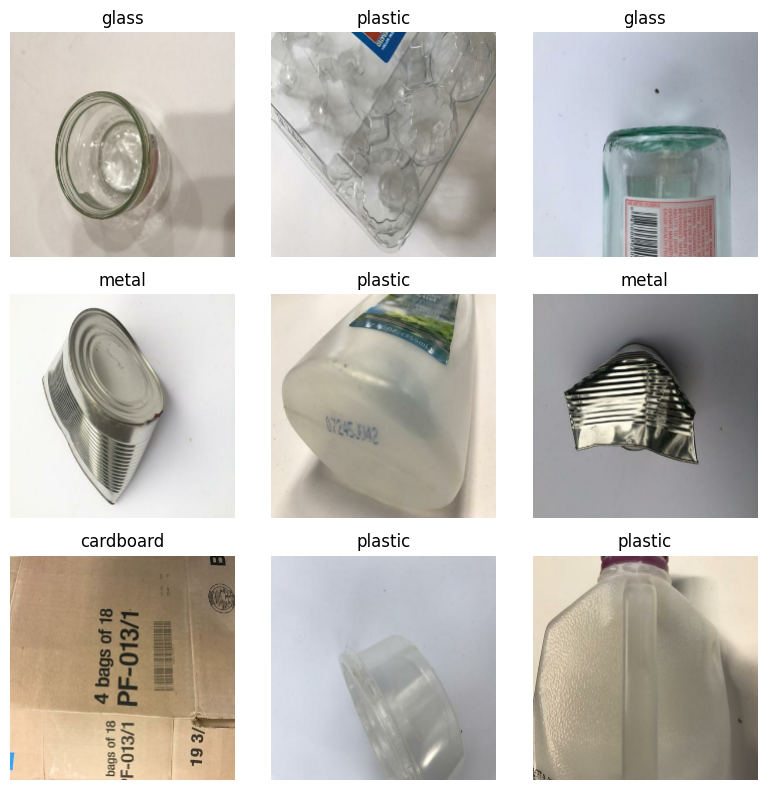

In [5]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

## Model Definition and Training

Now we will define a Convolutional Neural Network (CNN) model for the garbage classification task. We'll use a similar architecture to the CIFAR-10 example provided previously, adapting the input shape and the number of output classes.

In [6]:
# Normalize the image data
def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds.map(normalize_img)
val_ds = val_ds.map(normalize_img)


In [7]:
model = Sequential()

# Input layer: Adjust input shape to 224x224x3 for the garbage dataset
model.add(Input(shape=(224, 224, 3)))

# Convolutional and Pooling layers
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten the output for the dense layers
model.add(Flatten())

# Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer: Adjust to the number of classes in our garbage dataset
model.add(Dense(len(class_names), activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.3531 - loss: 1.5886 - val_accuracy: 0.4495 - val_loss: 1.3510
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.4649 - loss: 1.3426 - val_accuracy: 0.4535 - val_loss: 1.3063
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.5010 - loss: 1.2424 - val_accuracy: 0.4970 - val_loss: 1.1701
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.5648 - loss: 1.1349 - val_accuracy: 0.5149 - val_loss: 1.1791
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.6301 - loss: 1.0036 - val_accuracy: 0.5822 - val_loss: 1.1598


## Model Evaluation



16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 630ms/step - accuracy: 0.5822 - loss: 1.1598
Validation Loss: 1.1598
Validation Accuracy: 0.5822


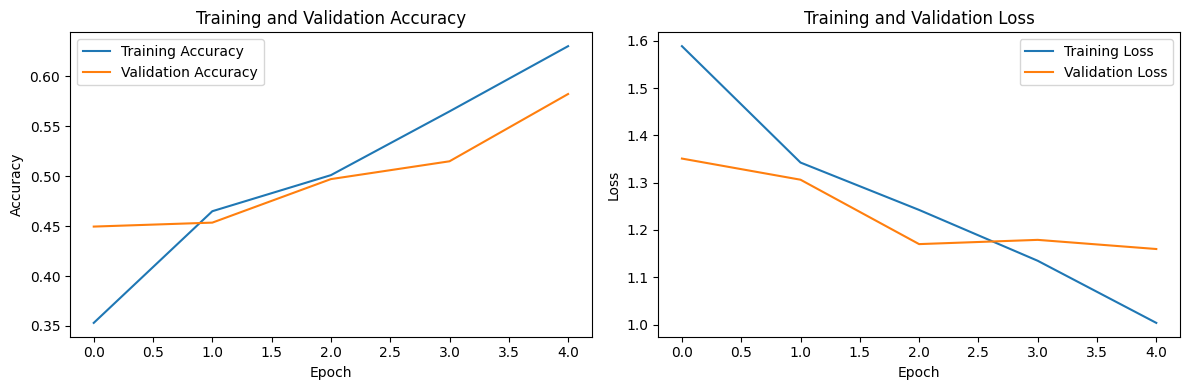

In [9]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Plot training and validation accuracy/loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Visualize Predictions



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step


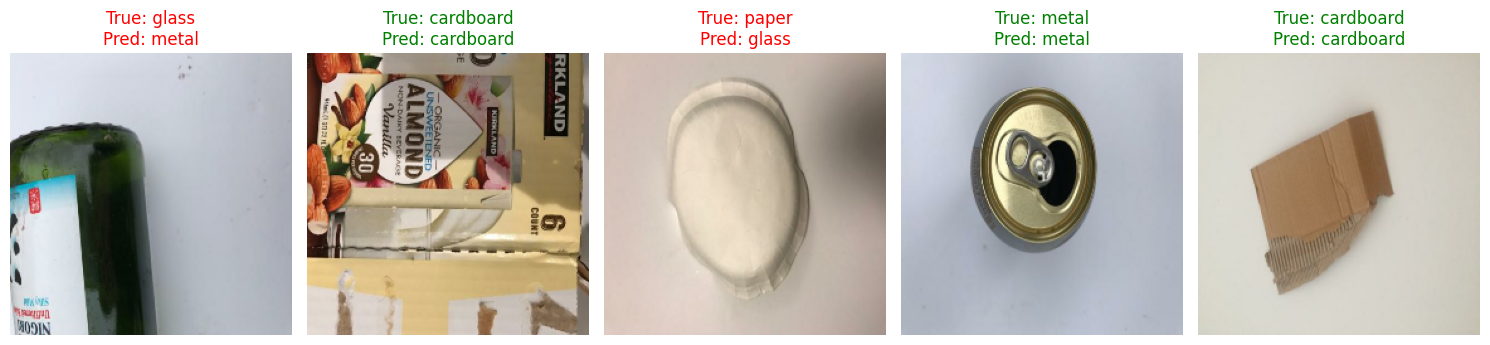

In [10]:
num_images_to_predict = 5

plt.figure(figsize=(15, 10))
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    for i in range(num_images_to_predict):
        plt.subplot(1, num_images_to_predict, i + 1)
        plt.imshow(images[i].numpy())
        predicted_label = np.argmax(predictions[i])
        true_label = labels[i].numpy()

        title_color = "green" if predicted_label == true_label else "red"
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}", color=title_color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    break
